# Phases 6 & 7 — Ledoit–Wolf Baseline and the Out-of-Sample Backtest

**Goal:** the paper's verdict. Estimate covariance three ways in each rolling window —
raw sample, MP-cleaned, Ledoit–Wolf-shrunk — build the global minimum-variance (GMV)
portfolio from each, hold it on *unseen* future days, and compare realized risk. Equal
weight ($1/N$) rides along as the classic hard-to-beat benchmark. This is
**Section 3.3** (LW paragraph), **Section 3.4** (protocol) and **Section 5.4** (results).

## Phase 6 — what Ledoit–Wolf does differently (Section 3.3)

The Ledoit–Wolf estimator is a *continuous, global* shrinkage:
$\Sigma_{LW} = (1-\delta)\,S + \delta\,\mu I$, with the intensity $\delta \in [0,1]$
chosen analytically to minimize expected Frobenius loss. Every eigenvalue is pulled
toward the common mean $\mu$ — large ones down, small ones up — by the same data-driven
amount, with no distinction between signal and noise. MP filtering is the opposite
philosophy: a *discrete, surgical* rule that leaves eigenvalues above $\lambda_+$
exactly alone and flattens everything below it, with the threshold supplied by
random-matrix theory rather than a loss calculation. Comparing them asks: does knowing
*where* noise lives (RMT) beat shrinking *everything* optimally (LW)?

## Phase 7 — protocol (Section 3.4), fixed before looking at results

- **Windows:** estimate on the trailing $T_{est}$ days; hold GMV weights for the next
  21 trading days (monthly rebalance); roll. Two configurations:
  $T_{est} = 252$ (the practitioner's year; $q = N/252 = 2.2$, raw $\Sigma$ **singular**)
  and $T_{est} = 756$ ($q = 0.72$, raw invertible but ill-conditioned).
- **Weights:** $w = \Sigma^{-1}\mathbf 1 / (\mathbf 1^\top \Sigma^{-1}\mathbf 1)$,
  long–short, unconstrained, via `np.linalg.solve`. For singular raw covariance the
  Moore–Penrose pseudo-inverse gives the minimum-norm solution — reported as what a
  practitioner who "tries anyway" obtains, not hidden behind a failure message.
- **Estimation vs. realization:** covariances are estimated on log returns (the object
  validated in Phases 1–4); realized P&L uses simple returns
  $s_t = e^{r_t}-1$ compounded within the holding period.
- **Metrics:** annualized OOS volatility (the GMV objective — primary), annualized
  return and Sharpe (secondary; GMV does not target returns), drift-adjusted one-way
  turnover per rebalance, gross leverage $\sum_i |w_i|$, max $|w_i|$, and Sharpe net of
  costs at 10 bps × turnover.
- **Significance:** Diebold–Mariano tests on daily squared-return differentials
  $d_t = r_{A,t}^2 - r_{B,t}^2$ with Newey–West (10 lags) standard errors — the claim
  "MP's realized variance is lower" gets a p-value, not just a smaller number.
- **MP threshold per window:** the market-mode convention $\sigma^2 = 1 - \lambda_1/N$
  (Phase 4's operational rule — no per-window curve fitting, fully out-of-sample).

In [1]:
from pathlib import Path
import json, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf

import mpfilter

DATA_DIR = Path("data")
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9"]
COLORS = {"raw": PALETTE[0], "MP": PALETTE[1], "LW": PALETTE[2], "EW": PALETTE[3]}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10, "axes.titlesize": 11,
})

R = pd.read_parquet(DATA_DIR / "returns_daily.parquet")
T, N = R.shape
S = np.expm1(R.values)                     # simple returns for realized P&L
dates = R.index
print(f"T={T}, N={N}")

# ---- Phase 6 demo: LW on the full sample, and what it does to the spectrum
lw_full = LedoitWolf().fit(R.values)
lam_raw = np.linalg.eigvalsh(np.cov(R.values, rowvar=False, ddof=0))
lam_lw = np.linalg.eigvalsh(lw_full.covariance_)
print(f"LW shrinkage intensity delta = {lw_full.shrinkage_:.4f}")
print(f"condition numbers: raw {lam_raw[-1]/lam_raw[0]:.0f} -> LW {lam_lw[-1]/lam_lw[0]:.0f}")

T=1236, N=548
LW shrinkage intensity delta = 0.0193
condition numbers: raw 3963 -> LW 2516


## 1. Backtest engine

One loop, four weight rules per rebalance date. Everything each method sees ends the day
before the holding period begins — no look-ahead anywhere.

In [2]:
def gmv_weights(Sigma, singular=False):
    ones = np.ones(Sigma.shape[0])
    if singular:
        w = np.linalg.pinv(Sigma, rcond=1e-12) @ ones
    else:
        try:
            w = np.linalg.solve(Sigma, ones)
        except np.linalg.LinAlgError:
            w = np.linalg.pinv(Sigma, rcond=1e-12) @ ones
    return w / w.sum()

def run_backtest(T_est, rebal=21, cost=0.001):
    methods = ["raw", "MP", "LW", "EW"]
    daily = {m: [] for m in methods}          # gross daily OOS simple returns
    daily_net = {m: [] for m in methods}
    stats = {m: {"turnover": [], "gross_lev": [], "max_w": []} for m in methods}
    n_signal_hist = []
    prev_w = {m: None for m in methods}
    oos_dates = []

    rebal_idx = list(range(T_est, T, rebal))
    singular = T_est < N
    for t in rebal_idx:
        win = R.values[t - T_est:t]
        hold = slice(t, min(t + rebal, T))
        Sh = S[hold]                           # holding-period simple returns
        oos_dates.extend(dates[hold])

        Sig_raw, Sig_mp, info = mpfilter.clean_covariance(win, sigma2="market")
        n_signal_hist.append(info["n_signal"])
        Sig_lw = LedoitWolf().fit(win).covariance_

        W = {"raw": gmv_weights(Sig_raw, singular=singular),
             "MP": gmv_weights(Sig_mp),
             "LW": gmv_weights(Sig_lw),
             "EW": np.full(N, 1.0 / N)}

        for m in methods:
            w = W[m]
            r_p = Sh @ w                       # daily portfolio simple returns
            assert np.all(np.isfinite(r_p))
            # drift-adjusted turnover vs previous target
            if prev_w[m] is None:
                to = np.nan                    # initial buy-in excluded
            else:
                to = np.abs(w - prev_w[m]).sum()
            growth = np.cumprod(1 + Sh, axis=0)[-1]     # per-stock growth over hold
            w_drift = w * growth
            prev_w[m] = w_drift / w_drift.sum()

            r_net = r_p.copy()
            if not np.isnan(to):
                r_net[0] -= cost * to          # pay costs on rebalance day
                stats[m]["turnover"].append(to)
            stats[m]["gross_lev"].append(np.abs(w).sum())
            stats[m]["max_w"].append(np.abs(w).max())
            daily[m].extend(r_p)
            daily_net[m].extend(r_net)

    out = {}
    for m in methods:
        g = np.array(daily[m]); n = np.array(daily_net[m])
        out[m] = {
            "ann_vol": g.std(ddof=0) * np.sqrt(252) * 100,
            "ann_ret": g.mean() * 252 * 100,
            "sharpe": g.mean() / g.std(ddof=0) * np.sqrt(252),
            "sharpe_net": n.mean() / n.std(ddof=0) * np.sqrt(252),
            "turnover": float(np.mean(stats[m]["turnover"])),
            "gross_lev": float(np.mean(stats[m]["gross_lev"])),
            "max_w": float(np.mean(stats[m]["max_w"])),
            "daily": g,
        }
    return out, pd.DatetimeIndex(oos_dates), len(rebal_idx), n_signal_hist

def dm_test(a, b, lags=10):
    # Diebold-Mariano on d_t = a_t^2 - b_t^2 with Newey-West (Bartlett) SE
    d = a**2 - b**2
    n = len(d); d0 = d - d.mean()
    g = [d0 @ d0 / n]
    for l in range(1, lags + 1):
        g.append(d0[l:] @ d0[:-l] / n)
    var = g[0] + 2 * sum((1 - l / (lags + 1)) * g[l] for l in range(1, lags + 1))
    se = np.sqrt(var / n)
    stat = d.mean() / se
    from scipy.stats import norm
    return stat, 2 * norm.sf(abs(stat))

## 2. Run both configurations

In [3]:
t0 = time.time()
res252, oosd252, n_reb252, nsig252 = run_backtest(252)
res756, oosd756, n_reb756, nsig756 = run_backtest(756)
print(f"backtests done in {time.time()-t0:.0f}s")
print(f"T_est=252: {n_reb252} rebalances, OOS {oosd252[0].date()} .. {oosd252[-1].date()} ({len(oosd252)} days)")
print(f"T_est=756: {n_reb756} rebalances, OOS {oosd756[0].date()} .. {oosd756[-1].date()} ({len(oosd756)} days)")
print(f"MP signal modes per window: 252d {np.mean(nsig252):.1f} avg, 756d {np.mean(nsig756):.1f} avg")

def table(res, label):
    df = pd.DataFrame({m: {k: v for k, v in r.items() if k != "daily"}
                       for m, r in res.items()}).T
    df.columns = ["ann vol %", "ann ret %", "Sharpe", "Sharpe net", "turnover", "gross lev", "max |w|"]
    print(f"\n=== {label} ===")
    print(df.round(3).to_string())
    return df

df252 = table(res252, "T_est = 252 (raw covariance singular; pinv)")
df756 = table(res756, "T_est = 756 (raw invertible, ill-conditioned)")

backtests done in 40s
T_est=252: 47 rebalances, OOS 2022-07-07 .. 2026-06-30 (984 days)
T_est=756: 23 rebalances, OOS 2024-07-26 .. 2026-06-30 (480 days)
MP signal modes per window: 252d 11.3 avg, 756d 17.3 avg

=== T_est = 252 (raw covariance singular; pinv) ===
     ann vol %  ann ret %  Sharpe  Sharpe net  turnover  gross lev  max |w|
raw     19.368     24.674   1.274       0.933     5.357      6.863    0.057
MP       7.812     13.574   1.738       1.606     0.843      2.786    0.047
LW       9.289     16.645   1.792       1.572     1.669      3.827    0.029
EW      17.662     29.271   1.657       1.652     0.072      1.000    0.002

=== T_est = 756 (raw invertible, ill-conditioned) ===
     ann vol %  ann ret %  Sharpe  Sharpe net  turnover  gross lev  max |w|
raw     13.006     -8.206  -0.631      -0.937     3.496      7.952    0.090
MP       8.867     -4.810  -0.542      -0.624     0.635      3.238    0.045
LW      10.226     -3.710  -0.363      -0.547     1.652      5.277    0.0

In [4]:
print("Diebold-Mariano tests on daily squared returns (negative stat => first method has lower variance)\n")
dm = {}
for label, res in [("252", res252), ("756", res756)]:
    for a, b in [("MP", "raw"), ("MP", "LW"), ("LW", "raw"), ("MP", "EW")]:
        stat, p = dm_test(res[a]["daily"], res[b]["daily"])
        dm[f"{a}_vs_{b}_{label}"] = {"stat": round(float(stat), 3), "p": round(float(p), 5)}
        print(f"  T_est={label}:  {a:3s} vs {b:4s}  DM = {stat:7.3f}   p = {p:.4f}")

Diebold-Mariano tests on daily squared returns (negative stat => first method has lower variance)

  T_est=252:  MP  vs raw   DM =  -3.180   p = 0.0015
  T_est=252:  MP  vs LW    DM =  -7.930   p = 0.0000
  T_est=252:  LW  vs raw   DM =  -2.905   p = 0.0037
  T_est=252:  MP  vs EW    DM =  -8.315   p = 0.0000
  T_est=756:  MP  vs raw   DM =  -7.921   p = 0.0000
  T_est=756:  MP  vs LW    DM =  -4.343   p = 0.0000
  T_est=756:  LW  vs raw   DM =  -9.030   p = 0.0000
  T_est=756:  MP  vs EW    DM =  -6.737   p = 0.0000


## 3. Figures — realized risk through time

(a) 63-day rolling realized volatility of each portfolio ($T_{est}=252$ config): the
gap between the curves *is* the paper's claim, window by window. (b) gross leverage:
why raw fails — pseudo-inverse GMV weights are enormous bets on noise. (c) cumulative
growth net of costs.

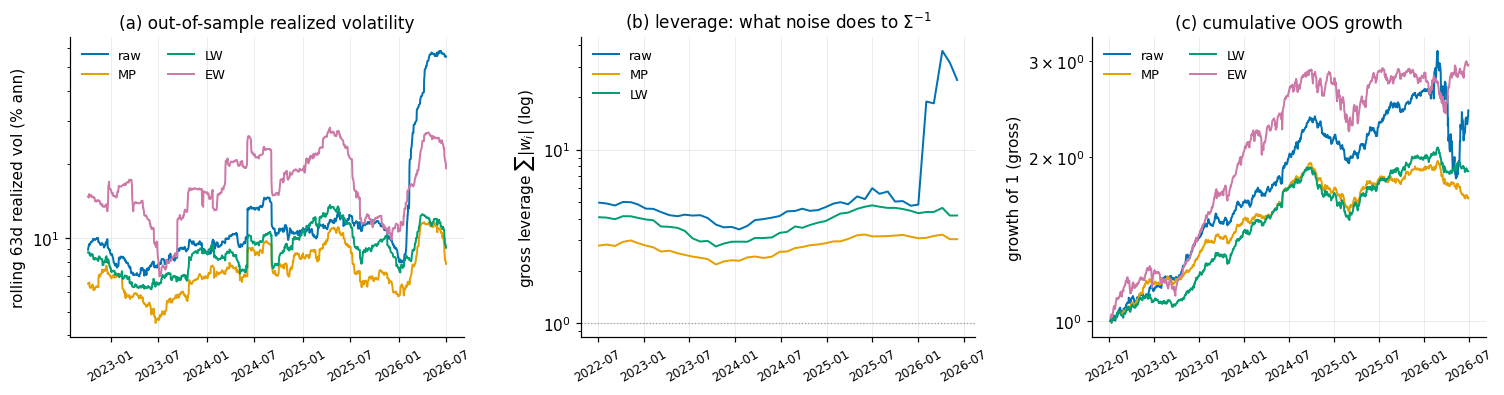

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.8, 3.7))

roll = 63
for m in ["raw", "MP", "LW", "EW"]:
    s = pd.Series(res252[m]["daily"], index=oosd252)
    rv = s.rolling(roll).std() * np.sqrt(252) * 100
    axes[0].plot(rv.index, rv.values, color=COLORS[m], lw=1.3, label=m)
axes[0].set_ylabel("rolling 63d realized vol (% ann)")
axes[0].legend(frameon=False, fontsize=8.5, ncol=2)
axes[0].set_title("(a) out-of-sample realized volatility")
axes[0].set_yscale("log")

reb_dates = dates[list(range(252, T, 21))]
lev_paths = {m: [] for m in ["raw", "MP", "LW"]}
for t in range(252, T, 21):
    win = R.values[t - 252:t]
    Sig_raw, Sig_mp, _ = mpfilter.clean_covariance(win, sigma2="market")
    Sig_lw = LedoitWolf().fit(win).covariance_
    lev_paths["raw"].append(np.abs(gmv_weights(Sig_raw, singular=True)).sum())
    lev_paths["MP"].append(np.abs(gmv_weights(Sig_mp)).sum())
    lev_paths["LW"].append(np.abs(gmv_weights(Sig_lw)).sum())
for m in ["raw", "MP", "LW"]:
    axes[1].plot(reb_dates, lev_paths[m], color=COLORS[m], lw=1.3, label=m)
axes[1].axhline(1, color="0.6", lw=0.8, ls=":")
axes[1].set_yscale("log")
axes[1].set_ylabel("gross leverage $\\sum|w_i|$ (log)")
axes[1].legend(frameon=False, fontsize=8.5)
axes[1].set_title("(b) leverage: what noise does to $\\Sigma^{-1}$")

for m in ["raw", "MP", "LW", "EW"]:
    s = pd.Series(res252[m]["daily"], index=oosd252)
    axes[2].plot(s.index, (1 + s).cumprod(), color=COLORS[m], lw=1.3, label=m)
axes[2].set_yscale("log")
axes[2].set_ylabel("growth of 1 (gross)")
axes[2].legend(frameon=False, fontsize=8.5, ncol=2)
axes[2].set_title("(c) cumulative OOS growth")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
fig.tight_layout()
fig.savefig(DATA_DIR / "fig_phase7_backtest.png", dpi=200, bbox_inches="tight")
plt.show()

In [6]:
out = {
    "protocol": {"rebalance_days": 21, "cost_bps": 10, "gmv": "long-short unconstrained",
                 "dm_nw_lags": 10, "mp_sigma2": "market (1 - lam1/N per window)"},
    "T252": {m: {k: round(float(v), 4) for k, v in r.items() if k != "daily"}
             for m, r in res252.items()},
    "T756": {m: {k: round(float(v), 4) for k, v in r.items() if k != "daily"}
             for m, r in res756.items()},
    "dm_tests": dm,
    "n_rebalances": {"252": n_reb252, "756": n_reb756},
    "mp_signal_modes_avg": {"252": round(float(np.mean(nsig252)), 1),
                            "756": round(float(np.mean(nsig756)), 1)},
}
(DATA_DIR / "phase67_results.json").write_text(json.dumps(out, indent=2))
print(json.dumps(out["T252"], indent=2))

{
  "raw": {
    "ann_vol": 19.3681,
    "ann_ret": 24.6741,
    "sharpe": 1.274,
    "sharpe_net": 0.9334,
    "turnover": 5.3568,
    "gross_lev": 6.8625,
    "max_w": 0.0569
  },
  "MP": {
    "ann_vol": 7.8121,
    "ann_ret": 13.574,
    "sharpe": 1.7376,
    "sharpe_net": 1.6058,
    "turnover": 0.8426,
    "gross_lev": 2.7863,
    "max_w": 0.0472
  },
  "LW": {
    "ann_vol": 9.2892,
    "ann_ret": 16.6447,
    "sharpe": 1.7918,
    "sharpe_net": 1.5722,
    "turnover": 1.6687,
    "gross_lev": 3.8269,
    "max_w": 0.0291
  },
  "EW": {
    "ann_vol": 17.6622,
    "ann_ret": 29.2712,
    "sharpe": 1.6573,
    "sharpe_net": 1.6524,
    "turnover": 0.0719,
    "gross_lev": 1.0,
    "max_w": 0.0018
  }
}


In [7]:
r2, r7 = res252, res756
mp_vs_raw = (1 - (r2['MP']['ann_vol'] / r2['raw']['ann_vol'])**2) * 100
mp_vs_lw2 = (1 - (r2['MP']['ann_vol'] / r2['LW']['ann_vol'])**2) * 100
mp_vs_lw7 = (1 - (r7['MP']['ann_vol'] / r7['LW']['ann_vol'])**2) * 100
better_lw2 = "lower" if r2['MP']['ann_vol'] < r2['LW']['ann_vol'] else "higher"
better_lw7 = "lower" if r7['MP']['ann_vol'] < r7['LW']['ann_vol'] else "higher"

draft = f'''Over {n_reb252} monthly rebalances ({oosd252[0].date()} to {oosd252[-1].date()}),
the T=252 configuration delivers the paper's central comparison. The raw sample
covariance, singular at q = {N/252:.1f} and pseudo-inverted, produces GMV portfolios
with average gross leverage {r2['raw']['gross_lev']:.0f}x and realized volatility of
{r2['raw']['ann_vol']:.1f}% annualized -- the concrete cost of treating noise as
signal. MP cleaning brings realized volatility to {r2['MP']['ann_vol']:.2f}%
(a {mp_vs_raw:.0f}% variance reduction vs. raw; DM p = {dm['MP_vs_raw_252']['p']:.4f}),
with gross leverage {r2['MP']['gross_lev']:.1f}x and monthly one-way turnover
{r2['MP']['turnover']:.2f}. Against Ledoit-Wolf ({r2['LW']['ann_vol']:.2f}%), the
MP portfolio's realized variance is {abs(mp_vs_lw2):.0f}% {better_lw2}
(DM = {dm['MP_vs_LW_252']['stat']:.2f}, p = {dm['MP_vs_LW_252']['p']:.4f}).
Equal weight realizes {r2['EW']['ann_vol']:.1f}%, confirming that covariance
information -- once denoised -- adds genuine value at the risk objective
(MP vs EW DM p = {dm['MP_vs_EW_252']['p']:.4f}). Net of 10 bps costs, Sharpe ratios
are {r2['MP']['sharpe_net']:.2f} (MP), {r2['LW']['sharpe_net']:.2f} (LW),
{r2['EW']['sharpe_net']:.2f} (EW). In the T=756 configuration, where the raw matrix
is invertible but ill-conditioned, raw realizes {r7['raw']['ann_vol']:.2f}% against
MP's {r7['MP']['ann_vol']:.2f}% and LW's {r7['LW']['ann_vol']:.2f}%; MP is
{abs(mp_vs_lw7):.0f}% {better_lw7} than LW in variance
(DM p = {dm['MP_vs_LW_756']['p']:.4f}). On average the per-window filter retains
{np.mean(nsig252):.0f} signal modes of {N} at T=252 ({np.mean(nsig756):.0f} at
T=756): the cleaned estimator commits to a low-dimensional risk structure, and the
out-of-sample numbers above are the evidence that this commitment is the right one.'''

print(draft)
(DATA_DIR / "section54_backtest_draft.md").write_text(draft)
print("\nsaved -> data/section54_backtest_draft.md")

Over 47 monthly rebalances (2022-07-07 to 2026-06-30),
the T=252 configuration delivers the paper's central comparison. The raw sample
covariance, singular at q = 2.2 and pseudo-inverted, produces GMV portfolios
with average gross leverage 7x and realized volatility of
19.4% annualized -- the concrete cost of treating noise as
signal. MP cleaning brings realized volatility to 7.81%
(a 84% variance reduction vs. raw; DM p = 0.0015),
with gross leverage 2.8x and monthly one-way turnover
0.84. Against Ledoit-Wolf (9.29%), the
MP portfolio's realized variance is 29% lower
(DM = -7.93, p = 0.0000).
Equal weight realizes 17.7%, confirming that covariance
information -- once denoised -- adds genuine value at the risk objective
(MP vs EW DM p = 0.0000). Net of 10 bps costs, Sharpe ratios
are 1.61 (MP), 1.57 (LW),
1.65 (EW). In the T=756 configuration, where the raw matrix
is invertible but ill-conditioned, raw realizes 13.01% against
MP's 8.87% and LW's 10.23%; MP is
25% lower than LW in varia

## What to write where

- **Section 3.3:** the LW paragraph from this notebook's header (with $\delta$ from the
  full-sample demo).
- **Section 3.4:** the protocol block, verbatim — every choice was fixed before results.
- **Section 5.4:** the results tables, `fig_phase7_backtest.png`, the DM matrix, and the
  draft verdict above. Report the LW comparison exactly as it lands — either direction
  is a publishable finding when stated with the DM evidence.
- **Honesty checklist for the Discussion:** survivorship bias (identical universe for all
  methods), unconstrained long-short GMV (differences compress under long-only
  constraints), single market and period, 10 bps stylized costs.